In [82]:
import pandas as pd
import numpy as np

In [83]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

In [84]:
import seaborn as sns

In [85]:
df = pd.read_csv("upi_transactions_mixed_upi_dataset.csv")

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87342 entries, 0 to 87341
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   receiver_upi_id          87342 non-null  object
 1   transaction_type         87342 non-null  object
 2   transaction_time(HH:MM)  87342 non-null  object
 3   date(DD/MM/YYYY)         87342 non-null  object
 4   amount(Rs.)              87342 non-null  int64 
 5   Fraud                    87342 non-null  object
dtypes: int64(1), object(5)
memory usage: 4.0+ MB


In [87]:
df.isnull().sum()

receiver_upi_id            0
transaction_type           0
transaction_time(HH:MM)    0
date(DD/MM/YYYY)           0
amount(Rs.)                0
Fraud                      0
dtype: int64

In [88]:
df.head(7)

,receiver_upi_id,transaction_type,transaction_time(HH:MM),date(DD/MM/YYYY),amount(Rs.),Fraud
0,amitsharma@ybl,Debited,15:42,11/06/2020,60366,No
1,urgentxpo@upi,Requested,16:07,25/08/2019,32347,Yes
2,supportgtc@secure,Requested,10:26,07/06/2025,150559,Yes
3,kycgee@upi,Requested,03:43,30/10/2021,160373,Yes
4,prizeiva@alert,Requested,01:56,11/09/2023,144160,Yes
5,supportgsx@secure,Requested,18:56,18/07/2020,143828,Yes
6,bharatpe@okhdfc,Debited,05:19,14/05/2017,131115,No


In [89]:
df.columns.tolist()

['receiver_upi_id',
 'transaction_type',
 'transaction_time(HH:MM)',
 'date(DD/MM/YYYY)',
 'amount(Rs.)',
 'Fraud']

In [90]:
df["Fraud"] = df["Fraud"].map({"No":0,"Yes":1})

In [91]:
df['Fraud'].value_counts()

Fraud
1    68021
0    19321
Name: count, dtype: int64

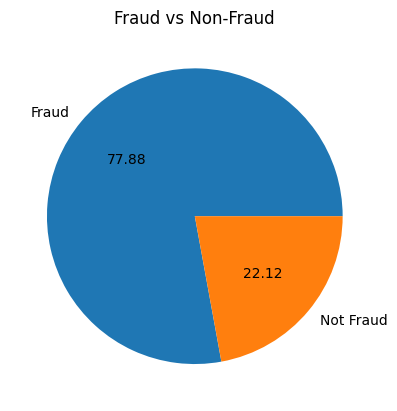

In [92]:
import matplotlib.pyplot as plt
plt.pie(df['Fraud'].value_counts(),labels=['Fraud','Not Fraud'], autopct="%0.2f")
plt.title("Fraud vs Non-Fraud")
plt.show()

In [93]:
df.sample(7)

,receiver_upi_id,transaction_type,transaction_time(HH:MM),date(DD/MM/YYYY),amount(Rs.),Fraud
23643,rohitverma3198@ibl,Debited,16:01,09/02/2017,33444,0
58939,priyareddy@oksbi,Debited,11:03,01/12/2026,19828,0
31750,amitroy@oksbi,Debited,12:58,20/02/2016,100719,0
58511,refundgsp@upi,Debited,03:09,03/08/2019,37742,1
59144,claimnrf@bank,Requested,14:38,09/09/2020,53103,1
29579,prizeakm@fast,Debited,09:20,04/07/2023,76236,1
24848,refundact@secure,Requested,05:18,13/04/2019,250,1


In [94]:
df.rename(columns={'date(DD/MM/YYYY)':'Date(DD/MM/YYYY)','amount(Rs.)':'Amount(Rs.)','Fraud':'is_Fraud'},inplace=True)
df.sample(7)

,receiver_upi_id,transaction_type,transaction_time(HH:MM),Date(DD/MM/YYYY),Amount(Rs.),is_Fraud
65580,prizerkr@secure,Requested,02:50,31/01/2021,140217,1
67008,refundlxj@bank,Requested,10:35,07/12/2023,64394,1
3837,cashbacksmg@alert,Requested,15:41,09/04/2019,14415,1
16652,urgentxjj@alert,Requested,01:11,05/07/2023,43070,1
67723,amitpatel@ybl,Debited,18:34,21/10/2017,43542,0
66019,lotteryqlj@bank,Debited,10:40,18/10/2016,112020,1
77572,claimmer@alert,Debited,04:12,06/10/2017,171263,1


In [95]:
df.duplicated().sum()
#If duplicates were there simply use-> df = df.drop_duplicates(keep='First')

np.int64(0)

In [96]:
df.shape

(87342, 6)

In [97]:
#Exploratory Data Analysis

In [98]:
#column names
#['receiver_upi_id','transaction_type','transaction_time(HH:MM)','date(DD/MM/YYYY)','amount(Rs.)','Fraud']
#receiver_upi_id -- text processing

In [99]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /home/kaka/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [100]:
#Number of characters in each UPI ID

In [101]:
df['num_char'] = df['receiver_upi_id'].apply(len)

In [102]:
df.head()

,receiver_upi_id,transaction_type,transaction_time(HH:MM),Date(DD/MM/YYYY),Amount(Rs.),is_Fraud,num_char
0,amitsharma@ybl,Debited,15:42,11/06/2020,60366,0,14
1,urgentxpo@upi,Requested,16:07,25/08/2019,32347,1,13
2,supportgtc@secure,Requested,10:26,07/06/2025,150559,1,17
3,kycgee@upi,Requested,03:43,30/10/2021,160373,1,10
4,prizeiva@alert,Requested,01:56,11/09/2023,144160,1,14


In [103]:
#Number of words using nltk.word_tokenize(lambda_variable) && then calculate no. of words of each id after tokenize
df['num_words'] = df['receiver_upi_id'].apply(lambda x: len(nltk.word_tokenize(x)))
#all id should have 3 parts as xyz@abc -> [xyz,@,abc]

In [104]:
df.head()

,receiver_upi_id,transaction_type,transaction_time(HH:MM),Date(DD/MM/YYYY),Amount(Rs.),is_Fraud,num_char,num_words
0,amitsharma@ybl,Debited,15:42,11/06/2020,60366,0,14,3
1,urgentxpo@upi,Requested,16:07,25/08/2019,32347,1,13,3
2,supportgtc@secure,Requested,10:26,07/06/2025,150559,1,17,3
3,kycgee@upi,Requested,03:43,30/10/2021,160373,1,10,3
4,prizeiva@alert,Requested,01:56,11/09/2023,144160,1,14,3


In [105]:
#df['num_words'] = df['receiver_upi_id'].apply(lambda x: nltk.sent_tokenize(x))
#--> Number of sentences using nltk.sent_tokenize(lambda_variable) && then calculate how much sentences in a row

In [106]:
#description of values
df[['num_char','num_words']].describe()

,num_char,num_words
count,87342.000000,87342.0
mean,14.411257,3.0
std,2.317130,0.0
min,8.000000,3.0
25%,13.000000,3.0
50%,14.000000,3.0
75%,16.000000,3.0
max,24.000000,3.0


In [107]:
#Describes values for is_Fraud=0 : Fraud=No(Safe Transaction)
df[df['is_Fraud']==0][['num_char','num_words']].describe()

,num_char,num_words
count,19321.000000,19321.0
mean,14.802753,3.0
std,3.800793,0.0
min,8.000000,3.0
25%,12.000000,3.0
50%,15.000000,3.0
75%,18.000000,3.0
max,24.000000,3.0


In [108]:
#Describes values for is_Fraud=1 : Fraud=Yes(Not Safe Transaction)
df[df['is_Fraud']==1][['num_char','num_words']].describe()

,num_char,num_words
count,68021.000000,68021.0
mean,14.300054,3.0
std,1.653815,0.0
min,10.000000,3.0
25%,13.000000,3.0
50%,14.000000,3.0
75%,15.000000,3.0
max,18.000000,3.0


<Axes: xlabel='num_char', ylabel='Count'>

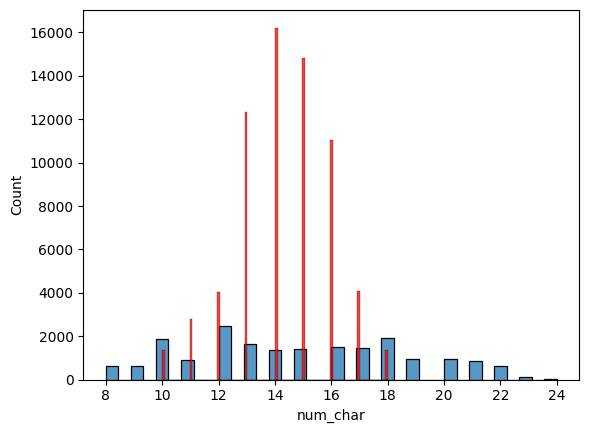

In [109]:
sns.histplot(df[df['is_Fraud']==0]['num_char'])
sns.histplot(df[df['is_Fraud']==1]['num_char'],color='Red')
#R-1: In fraud id: num_char is less but count high
#R-2: In non-fraud id: num_char is more but count is low
#Data Behavioural Representation

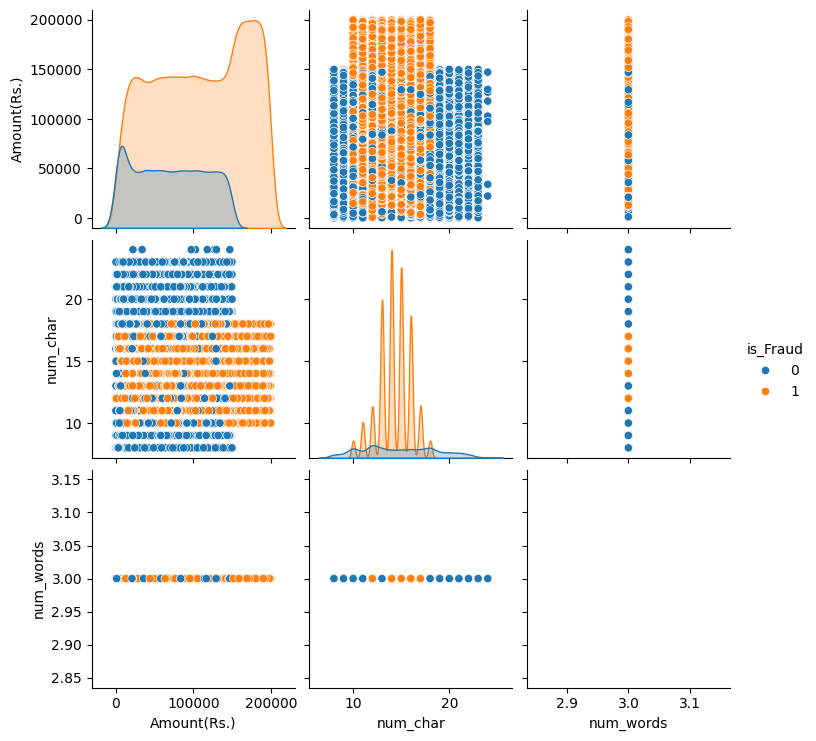

In [110]:
sns.pairplot(df,hue='is_Fraud') #Findis behavioural pattern

<Axes: >

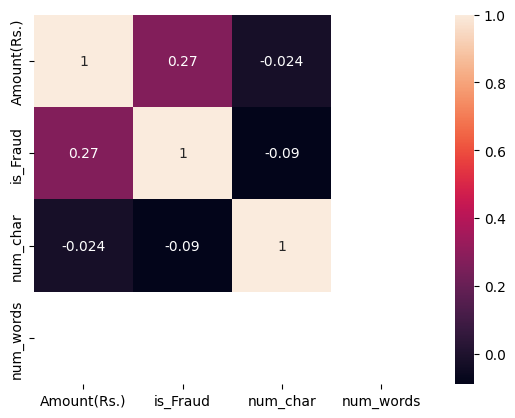

In [112]:
#Find correlation among the features(At first make all of these numeric values)
#Plot it into a heatmap 
df.drop(columns=['num_words'])
df.corr(numeric_only=True)
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [113]:
#Text : UPI ID preprocessing

In [127]:
def transform_text(text):
    text = text.lower() #LowerCase
    text = nltk.word_tokenize(text) #Word Split
    y=[] #Empty list
    for i in text:
        if i.isalnum():
            y.append(i) #Append except '@'
    return y

In [128]:
transform_text(df['receiver_upi_id'][79])

['rewardyvn', 'secure']